# 10b — Entrenamiento V5 FINAL (dataset completo 216, 2020-2025)

Entrena Faster R-CNN ResNet50-FPN con las **216 imágenes corregidas** (18 strata × 12),
leyendo la lista desde la tabla de seguimiento (`Estado == DONE`). Este es el modelo
**DEFINITIVO** de V5 para la comparación final V2/V3/V4/V5 en `08_mAP.ipynb`.

## 1. Imports y configuración

In [6]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torchvision
import rasterio
from rasterio.transform import rowcol
import geopandas as gpd
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

# ===================== CONFIG V5 FINAL =====================
GOLDEN_DIR    = r"D:\Silos\Golden_Dataset_1000"
CSV_PATH      = r"D:\Silos\seguimiento_gt_v5_final.csv"   # tabla COMPLETA (216 DONE)
MODEL_OUT     = r"D:\Silos\modelo_silos_v5_FINAL.pth"     # modelo DEFINITIVO (no _check)
MODEL_V4_PATH = r"D:\Silos\modelo_silos_v4_10k.pth"       # opcional, para comparar
GT_PREFIX     = "gt_"

TRAIN_RATIO = 0.85
SEED        = 456
NUM_EPOCHS  = 40      # modelo definitivo -> más épocas que el check
BATCH_SIZE  = 2
LR          = 0.005
CLIP_NORM   = 1.0
THRESHOLD   = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


## 2. Cargar las 216 corregidas desde la tabla y split train/val

Lee la tabla de seguimiento y toma TODAS las imágenes con `Estado == DONE`
(incluye los tiles "no hay silos" como fondo negativo).

In [7]:
# Leer la tabla final y tomar SOLO las V5_train corregidas
df = pd.read_csv(CSV_PATH)
selected = df.loc[
    (df["Estado"] == "DONE") & (df["Asignacion"] == "V5_train"),
    "ID_Imagen"
].astype(str).tolist()
print(f"Imágenes V5_train + DONE: {len(selected)}")

# Chequeo: Reserva NO debe entrar a train (es el test set)
n_reserva = ((df["Estado"] == "DONE") & (df["Asignacion"] == "Reserva")).sum()
print(f"En Reserva (excluidas de train, reservadas para test): {n_reserva}")

# Verificar existencia en disco
existentes = [f for f in selected if os.path.exists(os.path.join(GOLDEN_DIR, f))]
faltan = [f for f in selected if f not in existentes]
print(f"Encontradas en Golden: {len(existentes)}")
if faltan:
    print(f"[ADVERTENCIA] {len(faltan)} no encontradas:")
    for f in faltan[:10]:
        print("   ", f)

# Split determinístico train/val
random.seed(SEED)
files = existentes.copy()
random.shuffle(files)
split_idx = int(len(files) * TRAIN_RATIO)
train_files = files[:split_idx]
val_files   = files[split_idx:]
print(f"\ntrain={len(train_files)} | val={len(val_files)}")

Imágenes V5_train + DONE: 216
En Reserva (excluidas de train, reservadas para test): 54
Encontradas en Golden: 216

train=183 | val=33


## 3. Dataset class  *(RECONSTRUIDO)*

Lee TIF RGB + su `gt_*.shp` desde `GOLDEN_DIR`. Convierte polígonos geo→bbox píxel
(con reproyección y clamping). Tiles sin shp = fondo negativo.


In [8]:
class SilobolsaDataset(torch.utils.data.Dataset):
    def __init__(self, folder, file_list, gt_prefix="gt_"):
        self.folder = folder
        self.tifs = list(file_list)
        self.gt_prefix = gt_prefix
        self._shps = [f for f in os.listdir(folder) if f.endswith(".shp")]

    def __len__(self):
        return len(self.tifs)

    def _find_gt_shp(self, base):
        # busca gt_<base>.shp (o que empiece así)
        target = self.gt_prefix + base
        cand = next((s for s in self._shps if s.startswith(target)), None)
        return cand

    def _load_image(self, path):
        with rasterio.open(path) as src:
            try:
                img = src.read([1, 2, 3])
            except Exception:
                img = src.read()[:3]
            transform, crs = src.transform, src.crs
            H, W = src.height, src.width
        img = np.nan_to_num(img.astype(np.float32), nan=0.0)
        if np.max(img) > 255.0:
            img /= 10000.0
        elif np.max(img) > 1.0:
            img /= 255.0
        img = np.clip(img, 0, 1)
        return torch.as_tensor(img, dtype=torch.float32), transform, crs, H, W

    def _load_boxes(self, base, transform, raster_crs, H, W):
        shp = self._find_gt_shp(base)
        boxes = []
        if shp is None:
            return boxes  # tile sin silos -> fondo negativo
        try:
            gdf = gpd.read_file(os.path.join(self.folder, shp))
        except Exception:
            return boxes
        if gdf is None or len(gdf) == 0:
            return boxes
        if gdf.crs is not None and raster_crs is not None and gdf.crs != raster_crs:
            try:
                gdf = gdf.to_crs(raster_crs)
            except Exception:
                pass
        for geom in gdf.geometry:
            if geom is None or geom.is_empty:
                continue
            minx, miny, maxx, maxy = geom.bounds
            rows, cols = rowcol(transform, [minx, maxx], [maxy, miny])
            y1, y2 = sorted([float(rows[0]), float(rows[1])])
            x1, x2 = sorted([float(cols[0]), float(cols[1])])
            x1 = max(0.0, min(x1, W)); x2 = max(0.0, min(x2, W))
            y1 = max(0.0, min(y1, H)); y2 = max(0.0, min(y2, H))
            if (x2 - x1) > 1 and (y2 - y1) > 1:
                boxes.append([x1, y1, x2, y2])
        return boxes

    def __getitem__(self, idx):
        tif = self.tifs[idx]
        base = os.path.splitext(tif)[0]
        img, transform, crs, H, W = self._load_image(os.path.join(self.folder, tif))
        boxes = self._load_boxes(base, transform, crs, H, W)
        if len(boxes) == 0:
            target = {
                "boxes":    torch.zeros((0, 4), dtype=torch.float32),
                "labels":   torch.zeros((0,),  dtype=torch.int64),
                "image_id": torch.tensor([idx]),
                "area":     torch.zeros((0,),  dtype=torch.float32),
                "iscrowd":  torch.zeros((0,),  dtype=torch.int64),
            }
        else:
            bt = torch.as_tensor(boxes, dtype=torch.float32)
            target = {
                "boxes":    bt,
                "labels":   torch.ones((len(boxes),), dtype=torch.int64),
                "image_id": torch.tensor([idx]),
                "area":     (bt[:, 3] - bt[:, 1]) * (bt[:, 2] - bt[:, 0]),
                "iscrowd":  torch.zeros((len(boxes),), dtype=torch.int64),
            }
        return img, target


# Sanity check
_ds = SilobolsaDataset(GOLDEN_DIR, train_files, GT_PREFIX)
print(f"Dataset train: {len(_ds)} imágenes")
_img, _tgt = _ds[0]
print(f"Ejemplo -> imagen {tuple(_img.shape)}, cajas GT: {len(_tgt['boxes'])}")
n_vacios = sum(1 for i in range(len(_ds)) if len(_ds[i][1]["boxes"]) == 0)
print(f"Tiles sin silos (fondo negativo) en train: {n_vacios}")


Dataset train: 183 imágenes
Ejemplo -> imagen (3, 1024, 1024), cajas GT: 4
Tiles sin silos (fondo negativo) en train: 9


## 4. Modelo (mismo que V4: anchors chicos)

In [9]:
def get_model(num_classes=2):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None, weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


## 5. Training loop  *(RECONSTRUIDO)*

SGD + StepLR + gradient clipping. Checkpoint por época en `MODEL_OUT`.


In [10]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_ds = SilobolsaDataset(GOLDEN_DIR, train_files, GT_PREFIX)
val_ds   = SilobolsaDataset(GOLDEN_DIR, val_files,   GT_PREFIX)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)

model = get_model().to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

print(f"Entrenando V5 FINAL sobre {len(train_ds)} imágenes...\n")
for epoch in range(NUM_EPOCHS):
    model.train()
    running = 0.0
    for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        imgs = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM)
        optimizer.step()
        running += losses.item()
    lr_scheduler.step()
    print(f"Epoch {epoch+1}: loss medio = {running/len(train_loader):.4f}")
    torch.save(model.state_dict(), MODEL_OUT)
print("\nModelo guardado en:", MODEL_OUT)


Entrenando V5 FINAL sobre 183 imágenes...



Epoch 1/40: 100%|██████████| 92/92 [35:41<00:00, 23.28s/it]


Epoch 1: loss medio = 0.8984


Epoch 2/40: 100%|██████████| 92/92 [34:06<00:00, 22.25s/it]


Epoch 2: loss medio = 0.6352


...

Epoch 38: loss medio = 0.4621


Epoch 39/40: 100%|██████████| 92/92 [33:33<00:00, 21.89s/it]


Epoch 39: loss medio = 0.4585


Epoch 40/40: 100%|██████████| 92/92 [33:34<00:00, 21.89s/it]


Epoch 40: loss medio = 0.4581

Modelo guardado en: D:\Silos\modelo_silos_v5_FINAL.pth


## 6. Chequeo visual: GT (amarillo) vs Predicción V5 (cian)

Misma convención que QGIS. Sobre el set de validación (no visto en train).

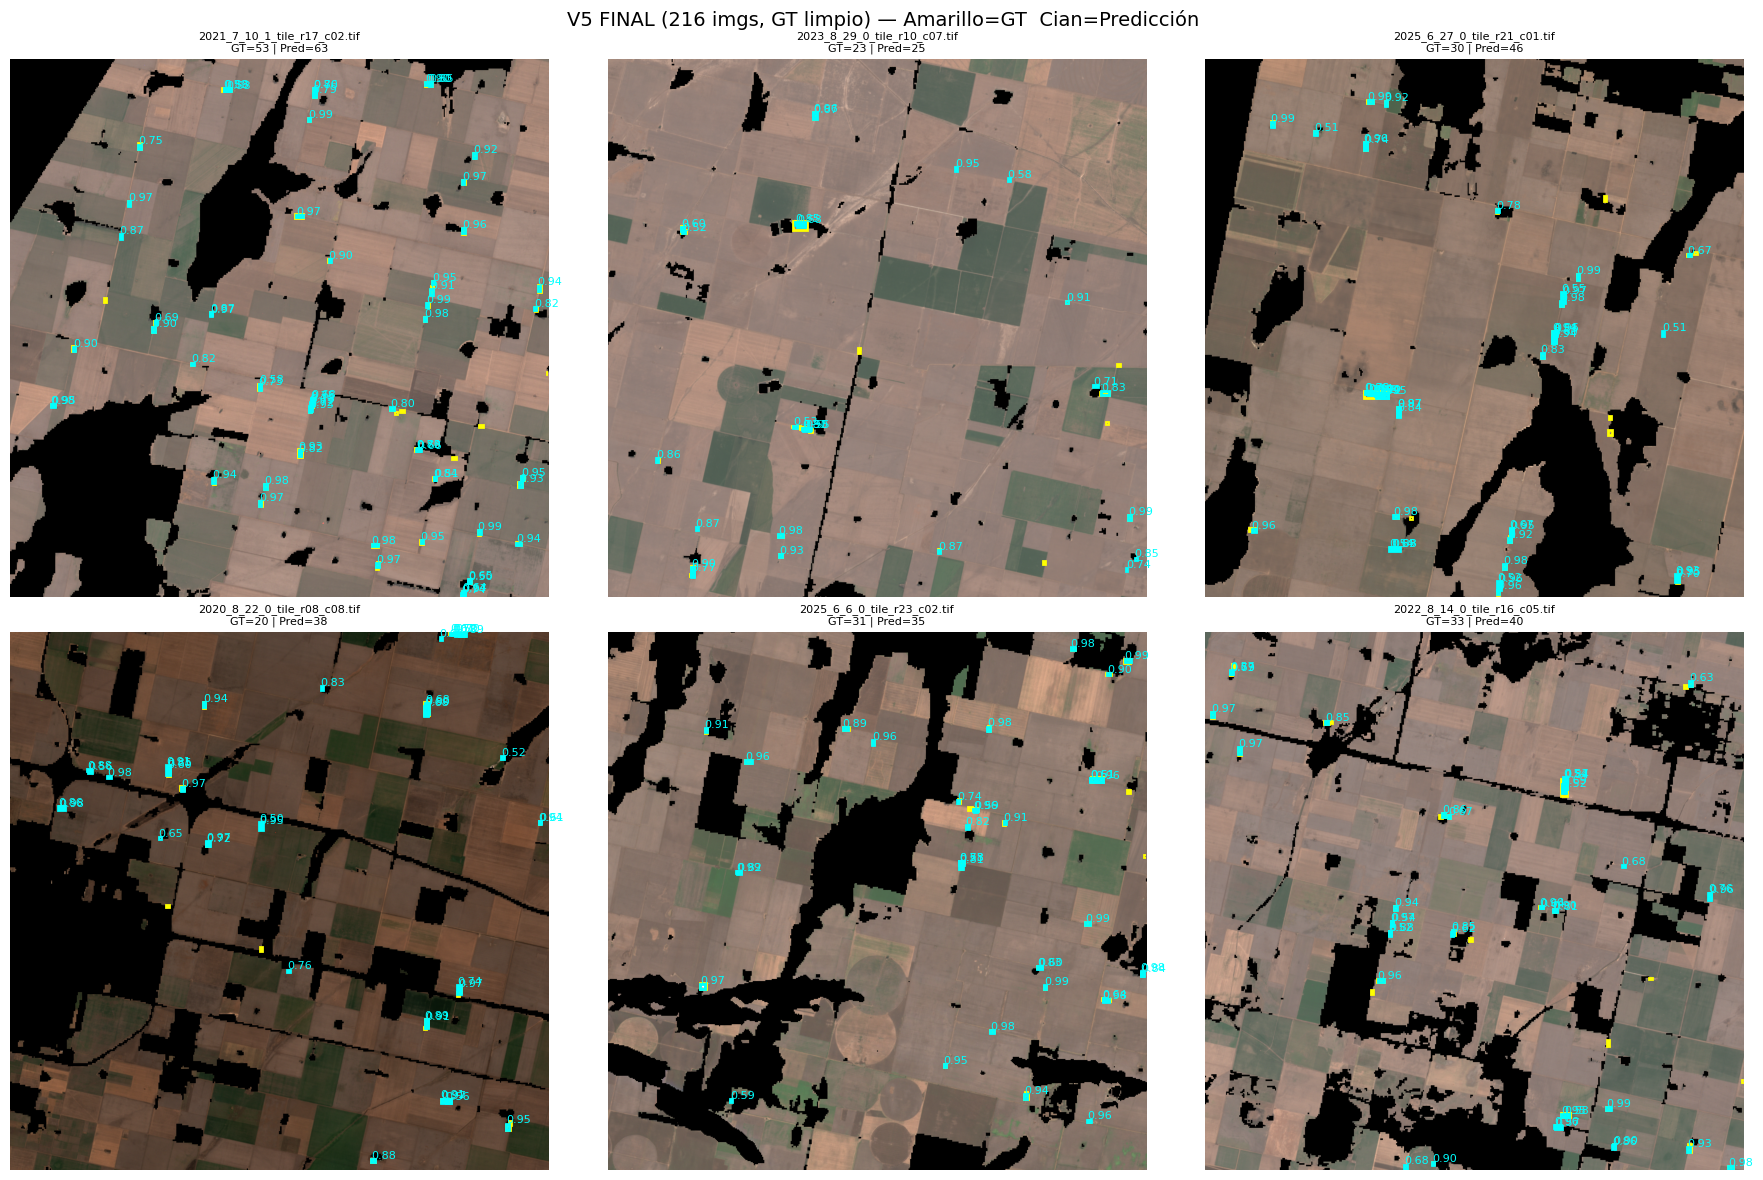

In [11]:
model.eval()
random.seed(42)
samples = random.sample(val_files, min(6, len(val_files)))
ds_val = SilobolsaDataset(GOLDEN_DIR, val_files, GT_PREFIX)
name_to_idx = {n: i for i, n in enumerate(ds_val.tifs)}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, img_name in enumerate(samples):
    idx = name_to_idx[img_name]
    img_tensor, target = ds_val[idx]
    with torch.no_grad():
        pred = model([img_tensor.to(device)])
    img_np = np.clip(img_tensor.numpy().transpose(1, 2, 0) * 2.5, 0, 1)
    axes[i].imshow(img_np)
    for b in target["boxes"].numpy():
        x1, y1, x2, y2 = b
        axes[i].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                          linewidth=2, edgecolor="yellow", facecolor="none"))
    boxes = pred[0]["boxes"].cpu().numpy()
    scores = pred[0]["scores"].cpu().numpy()
    n_det = 0
    for b, s in zip(boxes, scores):
        if s >= THRESHOLD:
            x1, y1, x2, y2 = b
            axes[i].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor="cyan", facecolor="none"))
            axes[i].text(x1, y1-2, f"{s:.2f}", color="cyan", fontsize=8)
            n_det += 1
    axes[i].set_title(f"{img_name}\nGT={len(target['boxes'])} | Pred={n_det}", fontsize=8)
    axes[i].axis("off")
plt.suptitle("V5 FINAL (216 imgs, GT limpio) — Amarillo=GT  Cian=Predicción", fontsize=14)
plt.tight_layout()
plt.show()


## 7. (Opcional) Comparación V4 vs V5

Amarillo=GT, Rojo(--)=V4, Cian=V5. Cautela: V4 vio muchas más imágenes y pudo
haber visto algunos de estos tiles; es referencia visual, no comparación rigurosa
(esa va con `08_mAP.ipynb`).


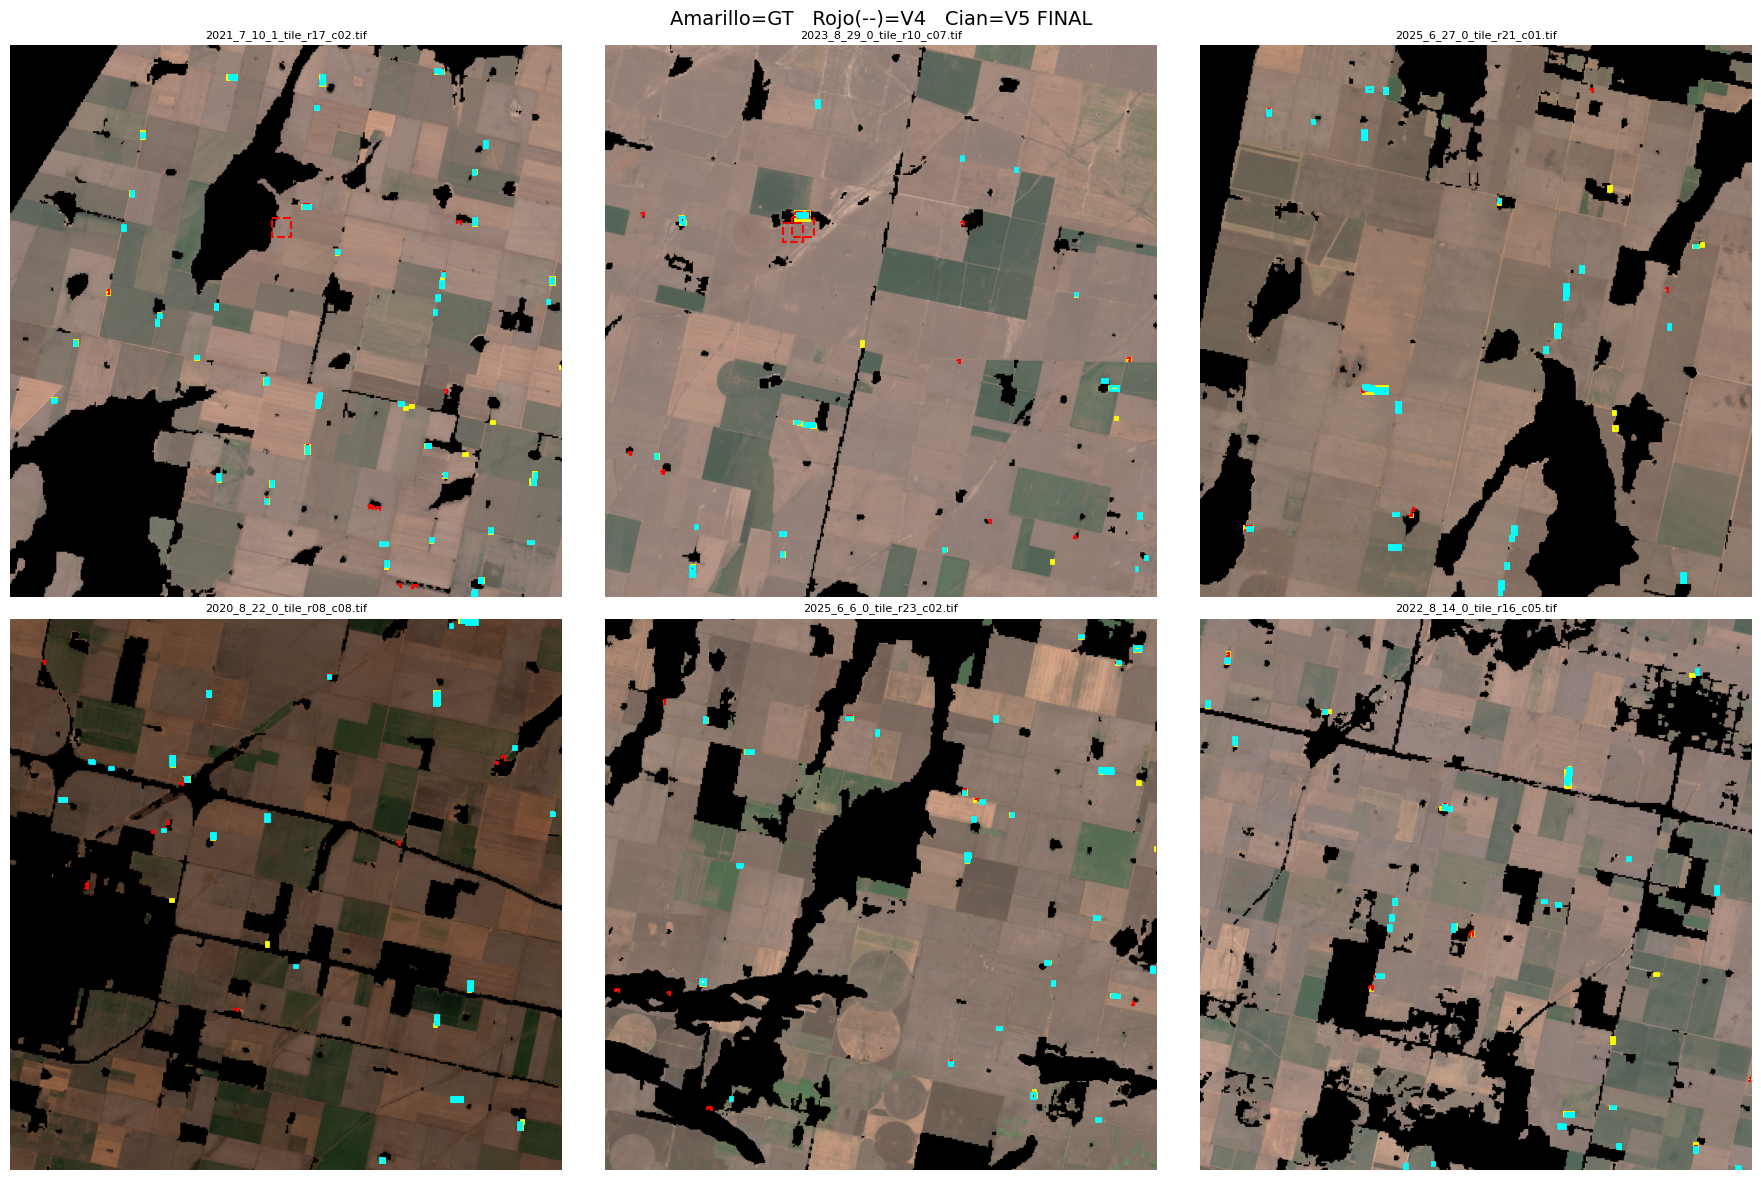

In [12]:
if os.path.exists(MODEL_V4_PATH):
    model_v4 = get_model().to(device)
    model_v4.load_state_dict(torch.load(MODEL_V4_PATH, map_location=device))
    model_v4.eval()
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    for i, img_name in enumerate(samples):
        idx = name_to_idx[img_name]
        img_tensor, target = ds_val[idx]
        with torch.no_grad():
            p5 = model([img_tensor.to(device)])
            p4 = model_v4([img_tensor.to(device)])
        img_np = np.clip(img_tensor.numpy().transpose(1, 2, 0) * 2.5, 0, 1)
        axes[i].imshow(img_np)
        for b in target["boxes"].numpy():
            x1, y1, x2, y2 = b
            axes[i].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor="yellow", facecolor="none"))
        for b, s in zip(p4[0]["boxes"].cpu().numpy(), p4[0]["scores"].cpu().numpy()):
            if s >= THRESHOLD:
                x1, y1, x2, y2 = b
                axes[i].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=1.5, edgecolor="red", facecolor="none", linestyle="--"))
        for b, s in zip(p5[0]["boxes"].cpu().numpy(), p5[0]["scores"].cpu().numpy()):
            if s >= THRESHOLD:
                x1, y1, x2, y2 = b
                axes[i].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor="cyan", facecolor="none"))
        axes[i].set_title(img_name, fontsize=8)
        axes[i].axis("off")
    plt.suptitle("Amarillo=GT   Rojo(--)=V4   Cian=V5 FINAL", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró V4 en:", MODEL_V4_PATH)


In [1]:
import torchvision
from torchvision.models import ResNet50_Weights
from torchvision.models.detection.rpn import AnchorGenerator

anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None, weights_backbone=ResNet50_Weights.DEFAULT,
    rpn_anchor_generator=anchor_generator
)

for name in ["conv1", "layer1", "layer2", "layer3", "layer4"]:
    mod = getattr(model.backbone.body, name)
    entrenable = any(p.requires_grad for p in mod.parameters())
    print(f"{name}: {'ENTRENABLE' if entrenable else 'CONGELADO'}")

conv1: CONGELADO
layer1: CONGELADO
layer2: ENTRENABLE
layer3: ENTRENABLE
layer4: ENTRENABLE
